<h1> German Articles Classifier </h1>
<p> In german language there are 3 types of articles (der - masculine, die - feminine, das - neutral)</p>
<p> Each noun has its article (it may seem strange, because in english there is no such thing)</p>
<p> On of the hardest aspects of learning german is remembering the articles, there are some patterns for it, but it is not that simple, in this project I will show whether a neural network can can classify the article of the noun by </p>
<p>- semantic meaning</p>
<p>- letters of the words</p>
<p>before starting, if you know german, how accurate do you think these models can get?</p> 

first the semantic meaning approach, we will download an embedding matrix (it contains a vector for each word corresponding to its meaning) from fasttext libary. It is trained on the german wikipedia

In [3]:
import fasttext
import fasttext.util
import os

if os.path.exists('cc.de.300.bin'):
    ft = fasttext.load_model('cc.de.300.bin')
else: 
    fasttext.util.download_model('de', if_exists='ignore')
    ft = fasttext.load_model('cc.de.300.bin')
ft.get_dimension()

300

In [4]:
print("total words:", len(ft.get_words()))

total words: 2000000


In [5]:
ft.get_words()[10000:10020]

['Wahnsinn',
 'übers',
 'konfrontiert',
 'natur',
 'Alters',
 'Posts',
 'Absolventen',
 'Au',
 'filtern',
 'Experiment',
 'Tante',
 'überwinden',
 'verpasste',
 'türkischer',
 '138',
 'weiblich',
 'Spalte',
 '1792',
 'Ice',
 'Kieler']

as we see, there are 2 mln words here. This is much more than in dictionaries because it also count specific dates, missspelled words etc. Lets see some synonyms of a word 'Kaiser'

In [6]:
synonym = ft.get_nearest_neighbors("Kaiser", k=3)
print(synonym)

[(0.8540111780166626, 'Kaisers'), (0.713546872138977, 'Kaiserin'), (0.7012115120887756, 'Kaisern')]


We can also see the similarity of the 2 chosen words with some linear algebra

In [7]:
import numpy as np

def get_similarity(word1, word2, model):
  
    vec1 = model.get_word_vector(word1)
    vec2 = model.get_word_vector(word2)
    
    
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    
    similarity = dot_product / (norm_vec1 * norm_vec2)
    return similarity

score = get_similarity("Kaiser", "König", ft)
print(f"Similarity score between words: {score:.4f}")



Similarity score between words: 0.5580


Let's create another table with the words and their articles

In [8]:
import pandas as pd

In [9]:
nomen = pd.read_csv("mit_artikeln.csv")
nomen = nomen.rename(columns={"ihm": "Nomen", "none": "Artikel"})
nomen.head()

,Nomen,Artikel
0,koennen,none
1,ich,n
2,sie,none
3,das,none
4,ist,n


In [10]:
nomen.shape

(308596, 2)

we have to drop all the words which are not nouns, we see that most of the words have feminine article. It is correct with the german language. We have to make the words start with a capital letter (german quirk).

In [11]:
nomen = nomen[nomen['Artikel'] != "none"]
nomen.value_counts("Artikel")

Artikel
f    14367
m    11379
n     7886
Name: count, dtype: int64

In [12]:
nomen['Nomen'] = nomen['Nomen'].str.capitalize()
nomen.head()
nomen.dropna(inplace=True)

now we have our table with articles prepared, let's get only those embeddings where the word in our table exists

In [13]:
embeddings = []
for wort in nomen['Nomen']:
    vec = ft.get_word_vector(wort)
    embeddings.append(vec)

In [14]:
print(len(embeddings))
print(len(nomen))

33631
33631


In [15]:
N = len(nomen)

In [16]:
embeddings[0]

array([-3.19043659e-02, -8.91396403e-02, -5.53509109e-02,  1.15659731e-02,
       -9.18156877e-02,  2.07584500e-01, -6.12394586e-02, -1.35522038e-02,
        1.39230201e-02,  2.32360139e-02,  5.79061247e-02, -8.18597004e-02,
        4.32634689e-02,  8.48752782e-02, -1.70675777e-02, -7.77099058e-02,
       -2.26764709e-01, -1.08045802e-01,  3.64755951e-02, -2.05659531e-02,
       -6.81079477e-02,  5.42096570e-02, -8.26675221e-02,  4.39864136e-02,
       -1.44711673e-01,  4.55614850e-02, -2.01111004e-01, -7.04792282e-03,
        5.29213585e-02,  1.72902141e-02,  1.03626169e-01, -1.04495855e-02,
       -7.34039815e-03,  2.34507322e-02, -1.97508521e-02, -1.71626173e-02,
       -2.82496959e-02, -2.94566959e-01, -1.38697103e-01,  4.62843180e-01,
        4.50491421e-02, -8.09598044e-02,  7.07977712e-02,  1.12021510e-02,
       -3.45973149e-02,  1.28914580e-01, -7.83806220e-02,  4.23526904e-03,
       -5.05329967e-02,  9.41945240e-02,  1.91071387e-02,  1.79621670e-02,
       -6.99718669e-02, -

In [17]:
nomen[2000:2005]


,Nomen,Artikel
5842,Boxen,n
5843,Angestellten,f
5845,Insgesamt,m
5846,Flecken,m
5853,Abbrechen,n


 we might not have to shuffle the data because the words that come first are the ones that are easier to learn (more people know the). This will simulate a learning person better

In [18]:
X = np.array(embeddings, dtype='float32')
y = nomen['Artikel'].values

In [19]:
mapping = {'f': 2, 'm': 1, 'n': 0}
y = np.array([mapping[artikel] for artikel in y])

In [20]:
y

array([0, 0, 0, ..., 2, 2, 2])

great, now we can add train, test and valid sets. As we previously told, we do not shuffle them

In [21]:
X_train = X[:10000]
y_train = y[:10000]
X_valid = X[10000:15000]
y_valid = y[10000:15000]
X_test = X[15000:]
y_test = y[15000:]


In [22]:
import tensorflow as tf

In [23]:
print("y_train type:", type(y_train[0]))    # Should be an int or float

y_train type: <class 'numpy.int32'>


we are ready to prepare our model, we will use tensorflow

In [24]:
artikel_guesser = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(300,)),
    tf.keras.layers.Dense(256, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation="softmax")
])

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights=True
)
artikel_guesser.compile(optimizer=optimizer,
                        loss = 'sparse_categorical_crossentropy',
                        metrics = ['accuracy'])
artikel_guesser.summary()

    



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               77056     
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 128)               16512     
                                                                 
 batch_normalization_2 (Bat  (None, 128)               

In [25]:
history = artikel_guesser.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[early_stop])

Epoch 1/100


313/313 [==============================] - 4s 5ms/step - loss: 0.5734 - accuracy: 0.7828 - val_loss: 0.6300 - val_accuracy: 0.8042
Epoch 2/100
313/313 [==============================] - 1s 3ms/step - loss: 0.2985 - accuracy: 0.8994 - val_loss: 0.2876 - val_accuracy: 0.9066
Epoch 3/100
313/313 [==============================] - 1s 3ms/step - loss: 0.2594 - accuracy: 0.9118 - val_loss: 0.2615 - val_accuracy: 0.9084
Epoch 4/100
313/313 [==============================] - 1s 4ms/step - loss: 0.2399 - accuracy: 0.9151 - val_loss: 0.2616 - val_accuracy: 0.9144
Epoch 5/100
313/313 [==============================] - 1s 3ms/step - loss: 0.2134 - accuracy: 0.9227 - val_loss: 0.2796 - val_accuracy: 0.9046
Epoch 6/100
313/313 [==============================] - 1s 3ms/step - loss: 0.1996 - accuracy: 0.9283 - val_loss: 0.2731 - val_accuracy: 0.9114
Epoch 7/100
313/313 [==============================] - 1s 4ms/step - loss: 0.1758 - accuracy: 0.9376 - val_loss: 0.2768 - val_accuracy: 0.90

In [28]:
artikel_guesser.evaluate(X_test, y_test)

583/583 [==============================] - 0s 822us/step - loss: 0.3548 - accuracy: 0.8705


[0.35481181740760803, 0.8705383539199829]

our accuracy is about 95%, this is far better than I expected. It might suggest that most of articles in german make sense

583/583 [==============================] - 1s 986us/step


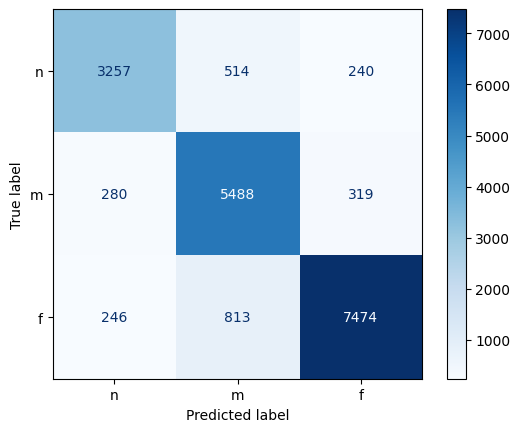

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = artikel_guesser.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['n', 'm', 'f'])
disp.plot(cmap=plt.cm.Blues)

In [30]:
reverse_mapping = {0 : 'Neutrum', 1 : 'Maskulinum', 2 : 'Femininum'}
dmapping = {0 : 'das', 1 : 'der', 2 : 'die'}
dmapping2 = {'n' : 'das', 'm' : 'der', 'f' : 'die'}

you can now see some words and which articles are predicted for them

In [31]:
def give_artikel(wort, model=artikel_guesser,mapping=dmapping,):
    wort_vec = np.array(ft.get_word_vector(wort), dtype='float32')
    wort_vec = wort_vec.reshape(1,-1)
    probas = model.predict(wort_vec)
    print(str(mapping[np.argmax(probas)]) + " " + wort)

def give_artikel_return(wort, model=artikel_guesser,mapping=dmapping,):
    wort_vec = np.array(ft.get_word_vector(wort), dtype='float32')
    wort_vec = wort_vec.reshape(1,-1)
    probas = model.predict(wort_vec)
    return str(mapping[np.argmax(probas)])
    

In [32]:
give_artikel('Katze') #write the word you want to test here

1/1 [==============================] - 0s 21ms/step
die Katze


In [ ]:
nomen.loc[nomen['Nomen'] == 'Katze']['Artikel'].iloc[0] 
# additional code, for future pandas use :)
#it is like SELECT * FROM nomen WHERE Nomen == 'Katze'

'f'

In [37]:
def true_artikel(wort, nomen=nomen, mapping=dmapping2):
    art = nomen.loc[nomen['Nomen'] == wort]['Artikel'].iloc[0]
    d = mapping[art]
    print(d + " " + wort)

def true_artikel_return(wort, nomen=nomen, mapping=dmapping2):
    art = nomen.loc[nomen['Nomen'] == wort]['Artikel'].iloc[0]
    d = mapping[art]
    return d

In [39]:
true_artikel('Katze') #this function gives the correct article with a clean output 

die Katze


here are some random 50 words to be evaluated

In [40]:
zahl = 50
worter = nomen['Nomen'].sample(zahl)
worter = worter.values
worter

array(['Entkommen', 'Notgenerator', 'Seitennummer', 'Begnadigung',
       'Spezifikum', 'Feuerrad', 'Erguss', 'Windbrecher', 'Blot',
       'Milchbart', 'Austauschbar', 'Spirale', 'Marktforschungsabteilung',
       'Bremsspuren', 'Lotleine', 'Sauerstoffmaske', 'Festnageln',
       'Klingelknopf', 'Zwilling', 'Insult', 'Heilung', 'Gesundheitsamt',
       'Sportklub', 'Hodenhochstand', 'Hausmannskost', 'Klunker',
       'Dollar', 'Hund', 'Schied', 'Passkontrollen', 'Deck', 'Holzboden',
       'Pfeifsignal', 'Kote', 'Platin', 'Abdichten', 'Ebene',
       'Hellseherei', 'Fiasko', 'Schutzvorrichtung', 'Umzug',
       'Nacktszene', 'Geldeintreibung', 'Kontinuum', 'Locke', 'Fockrahe',
       'Gruppierung', 'Schorf', 'Antillen', 'Vorgeschmack'], dtype=object)

In [42]:
def Ergebnis(worter): # function to test the model with multiple words
    for w in worter:
        print("vorausgesagt Ergebnis: ")
        give_artikel(w)
        print("richtige Ergebnis:")
        true_artikel(w)
        print()
        
        

In [43]:
Ergebnis(worter)

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 9ms/step
das Entkommen
richtige Ergebnis:
das Entkommen

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 17ms/step
der Notgenerator
richtige Ergebnis:
der Notgenerator

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 18ms/step
die Seitennummer
richtige Ergebnis:
die Seitennummer

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 9ms/step
die Begnadigung
richtige Ergebnis:
die Begnadigung

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 25ms/step
das Spezifikum
richtige Ergebnis:
das Spezifikum

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 15ms/step
das Feuerrad
richtige Ergebnis:
das Feuerrad

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 17ms/step
der Erguss
richtige Ergebnis:
der Erguss

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 10ms/step
der Windbrecher
richtige Ergebnis:
der Windbrech

# Now we will make predictions based on letter permutation

but this is a multi layer perceptron model, we need the same number of inputs every time, and we need to change the letter into some numbers for our model to work, how to do it?

We will take a fixed number of letters (there is a constant named MAXLEN and this is exactly how many we are going to take). But why? In german there are words with 3 letters and 33 letters. Yes but
- we can fill the rest of the short words with zeros (so the computer reads 'Katze00000' instead of 'Katze'), like a zero padding in CNNs
- we can cut the ending of the words so that only the last 10 characters matters for example for the word 'Geschwindigkeibeschränkung' (velocity limit) we will take only 'schränkung' in this case this is a completely different word, but both of these have an article 'die' so it does not matter.

Also the last characters matters most so we will actually have to reverse the words to get a more accurate score. For example words with endings 'ung' or 'keit' have almost always 'die'. But we are not comparing a sequence here so we need the endings of the words at static place. So that the last letter (which matters the most) is actually the first place for a computer to reed

In [45]:
MAXLEN = 10

categories = ['a',  'b'	,'c',	'd',	'e',	'f',	'g',	'h'	,   'i',	'j',	'k',	'l',	'm',
              	'n',	'o',	'p',	'q',	'r',	's',	't',	'u',	'v',	'w',
                    	'x',	'y',	'z'	,'ä'	,'ö'	,'ü',	'ß', '0']
def word_prep(w, MAXLEN):
    w = w.lower()
    r = []
    n = min(len(w), MAXLEN)
    for i in range(-1, -n-1,-1):
        r.append(w[i])
    if(n < MAXLEN):
        for i in range(MAXLEN-n):
            r.append('0')
    return r

def onehot(cat):
    n = len(cat)
    oh = []
    for i in range(n):
        vec = [0] * n
        vec[i] = 1
        oh.append(vec)
    oh.append([0]*n)
    return oh

OneHot = onehot(categories)
hot_mapping = dict(zip(categories, OneHot))

our letters are actually nominal variables, so we need to encode them in a one-hot way 
I decided to make a one hot 'embedding' matrix manually, because why not!
for example a is [1, 0, 0....] b is [0, 1, 0, 0, ..., 0] etc
oh and '0' (the padding) has a vector of all zeros

In [47]:
def hotX(w,MAXLEN):
    r = word_prep(w,MAXLEN)
    HX = [hot_mapping[letter] for letter in r]
    flatHX = [item for sublist in HX for item in sublist] #flatten the list of lists into a vector
    return np.array(flatHX, dtype='int8')

In [48]:
X2 = nomen['Nomen'].values
X2 = [hotX(w, MAXLEN) for w in X2]
X2 = np.stack(X2)

In [49]:
X2.shape
X2_train = X2[:10000]
X2_valid= X2[10000:15000]
X2_test = X2[15000:]

now our data is ready, the inputs are vectors with a length of 310, because there are 30 letters in german alphabet and we also need a one hot vector for 0 (short words padding)

In [52]:
artikel_guesser2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(310,)),
    tf.keras.layers.Dense(256, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='swish', kernel_initializer="he_normal"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation="softmax")
])

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights=True
)
artikel_guesser2.compile(optimizer=optimizer,
                        loss = 'sparse_categorical_crossentropy',
                        metrics = ['accuracy'])
artikel_guesser2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 256)               79616     
                                                                 
 batch_normalization_4 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dense_6 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_5 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dense_7 (Dense)             (None, 128)               16512     
                                                                 
 batch_normalization_6 (Bat  (None, 128)              

In [53]:
historyL = artikel_guesser2.fit(X2_train, y_train, epochs=100, validation_data=(X2_valid, y_valid), callbacks=[early_stop])

Epoch 1/100
313/313 [==============================] - 3s 4ms/step - loss: 0.9768 - accuracy: 0.5850 - val_loss: 0.8110 - val_accuracy: 0.6694
Epoch 2/100
313/313 [==============================] - 1s 3ms/step - loss: 0.7385 - accuracy: 0.6906 - val_loss: 0.6409 - val_accuracy: 0.7414
Epoch 3/100
313/313 [==============================] - 1s 4ms/step - loss: 0.6536 - accuracy: 0.7300 - val_loss: 0.6088 - val_accuracy: 0.7562
Epoch 4/100
313/313 [==============================] - 1s 4ms/step - loss: 0.5888 - accuracy: 0.7593 - val_loss: 0.5888 - val_accuracy: 0.7710
Epoch 5/100
313/313 [==============================] - 1s 4ms/step - loss: 0.5528 - accuracy: 0.7762 - val_loss: 0.5704 - val_accuracy: 0.7792
Epoch 6/100
313/313 [==============================] - 1s 3ms/step - loss: 0.5081 - accuracy: 0.7994 - val_loss: 0.5579 - val_accuracy: 0.7872
Epoch 7/100
313/313 [==============================] - 1s 4ms/step - loss: 0.4806 - accuracy: 0.8066 - val_loss: 0.5694 - val_accuracy: 0.7868

In [54]:
artikel_guesser2.evaluate(X2_test, y_test)

583/583 [==============================] - 1s 885us/step - loss: 0.5068 - accuracy: 0.8043


[0.5068033933639526, 0.804250955581665]

we get 80%, that is quite what I expected. it is worse than the score from the first guesser, however the values of an embedding matrix might be a bit correlated with the article of the noun, so the conclusions from the second test are much more reliable. 

In [56]:
def give_artikel2_return(wort, model=artikel_guesser2,mapping=dmapping,):
    wort_vec = hotX(wort, MAXLEN).reshape(1,-1)
    probas = model.predict(wort_vec)
    return str(mapping[np.argmax(probas)])

def give_artikel2(wort, model=artikel_guesser2,mapping=dmapping,):
    wort_vec = hotX(wort, MAXLEN).reshape(1,-1)
    probas = model.predict(wort_vec)
    print(str(mapping[np.argmax(probas)]) + " " + wort)

def Ergebnis2(worter):
    for w in worter:
        print("vorausgesagt Ergebnis: ")
        give_artikel2(w, model=artikel_guesser2)
        print("richtige Ergebnis:")
        true_artikel(w)
        print()

In [57]:
zahl = 50
worter = nomen['Nomen'].sample(zahl)
worter = worter.values
Ergebnis2(worter)

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 75ms/step
der Speicherring
richtige Ergebnis:
der Speicherring

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 18ms/step
das Windmesser
richtige Ergebnis:
der Windmesser

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 21ms/step
die Arbeitsteilung
richtige Ergebnis:
die Arbeitsteilung

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 17ms/step
das Zehnfache
richtige Ergebnis:
das Zehnfache

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 16ms/step
das Chinesenviertel
richtige Ergebnis:
das Chinesenviertel

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 17ms/step
die Thronerbin
richtige Ergebnis:
die Thronerbin

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 16ms/step
das Holzbein
richtige Ergebnis:
das Holzbein

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 17ms/step
die Vorwahl
richtige Ergeb

In [ ]:
Ergebnis2(['Sonne']) 
# here you can try a second Model, 
#remember about capital Letters in Nouns!

vorausgesagt Ergebnis: 
1/1 [==============================] - 0s 17ms/step
die Sonne
richtige Ergebnis:
der Sonne



In [63]:
print(give_artikel2_return('Joghurt'))#here are only predictions, you can try some non existing words

1/1 [==============================] - 0s 11ms/step
der


here are some roles for articles in german
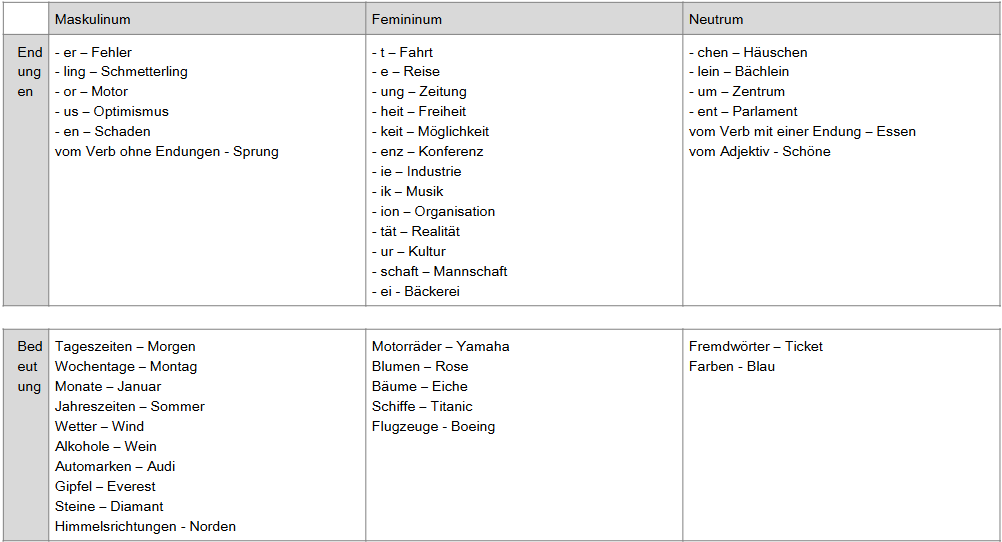

In [72]:
def give_probas(wort, model=artikel_guesser2,mapping=dmapping,):
    wort_vec = hotX(wort, MAXLEN).reshape(1,-1)
    probas = model.predict(wort_vec)
    print (f'proba for die, [{mapping[2]}]: {probas[0][2] * 100:.1f}%')
    print (f'proba for der, [{mapping[1]}]: {probas[0][1] * 100:.1f}%')
    print (f'proba for das, [{mapping[0]}]: {probas[0][0] * 100:.1f}%')

let's try some rules!

In [82]:
give_probas('ung')

1/1 [==============================] - 0s 15ms/step
proba for die, [die]: 20.3%
proba for der, [der]: 69.7%
proba for das, [das]: 9.9%


this is weird, what will happen if the word will get longer

In [ ]:
give_probas('SIGMAung')

1/1 [==============================] - 0s 32ms/step
proba for die, [die]: 99.1%
proba for der, [der]: 0.8%
proba for das, [das]: 0.1%


In [83]:
give_probas('chen')

1/1 [==============================] - 0s 20ms/step
proba for die, [die]: 12.9%
proba for der, [der]: 32.4%
proba for das, [das]: 54.7%


In [84]:
give_probas('SIGMAchen')

1/1 [==============================] - 0s 18ms/step
proba for die, [die]: 1.0%
proba for der, [der]: 0.4%
proba for das, [das]: 98.7%


In [85]:
give_probas('um')

1/1 [==============================] - 0s 16ms/step
proba for die, [die]: 7.0%
proba for der, [der]: 52.0%
proba for das, [das]: 41.0%


In [86]:
give_probas('umumumumum')

1/1 [==============================] - 0s 15ms/step
proba for die, [die]: 1.7%
proba for der, [der]: 1.8%
proba for das, [das]: 96.5%


In [87]:
give_probas('Schmetterling')

1/1 [==============================] - 0s 17ms/step
proba for die, [die]: 0.7%
proba for der, [der]: 91.0%
proba for das, [das]: 8.3%


In [88]:
give_probas('ling')

1/1 [==============================] - 0s 15ms/step
proba for die, [die]: 1.2%
proba for der, [der]: 89.0%
proba for das, [das]: 9.8%


interesting, the characteristical endings itself does not give accurate results, but when the word is longer the rule is satisfied (it can even make no sense). Schmetterling is an exception.